In [1]:
import time
import numpy as np
import xarray as xr
import ast
from datetime import datetime, timedelta
from workers.processing import find_centroid, find_stars
from workers.compression import crop_centre, crop_sidelobes_old, crop_sidelobes, crop_areas
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
raw_filename = "/home/toliman-dev/toliman/imageservice/imageservice/images/simulated/toliman_image_00.npy"
raw_image = np.load(raw_filename)

In [3]:
metadata_file = raw_filename.strip(".npy")+".txt"

with open(metadata_file, "r") as file:
    for line in file:
        header = ast.literal_eval(line.strip())

In [4]:
%%time
# Crop core and sidelobes from raw image
centroid_data = find_centroid(raw_image)
core = crop_centre(raw_image, centroid_data["x"], centroid_data["y"])
star_poss = find_stars(core)
x_poss = np.round(star_poss['xs'] + centroid_data['x'] - core.shape[1]//2)
y_poss = np.round(star_poss['ys'] + centroid_data['y'] - core.shape[0]//2)
sidelobes = crop_sidelobes(raw_image, x_poss, y_poss, centroid_data)

CPU times: user 396 ms, sys: 150 ms, total: 546 ms
Wall time: 555 ms


In [5]:
header["CAMTIME"] = str(header["CAMTIME"])

    # Add position information to header
header["CENTR_X"] = int(np.round(centroid_data['x']))
header["CENTR_Y"] = int(np.round(centroid_data['y']))
header["STAR_1_X"] = int(x_poss[0])
header["STAR_1_Y"] = int(y_poss[0])
header["STAR_2_X"] = int(x_poss[1])
header["STAR_2_Y"] = int(y_poss[1])

In [6]:
header

{'SEQNUM': 0,
 'CAMTIME': '22540362524944',
 'COMTIME': '2025-04-08 15:55:43.682742',
 'EXPOSURE': 46.0,
 'PXLFMT': 'Mono16',
 'XOFF': 912,
 'YOFF': 0,
 'XPAD': 0,
 'YPAD': 0,
 'CENTR_X': 1824,
 'CENTR_Y': 1824,
 'STAR_1_X': 1829,
 'STAR_1_Y': 1833,
 'STAR_2_X': 1819,
 'STAR_2_Y': 1815}

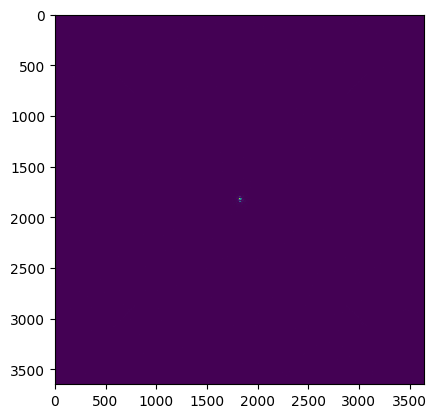

In [7]:
plt.imshow(raw_image, aspect=1, interpolation='nearest');

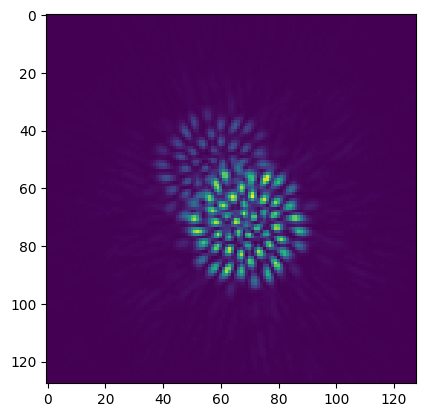

In [8]:
plt.imshow(core, aspect=1, interpolation='nearest');

In [9]:
centroid_data

{'x': np.float64(1823.500644814733),
 'y': np.float64(1823.6904068275014),
 't': '2026-02-16 15:20:06.815525'}

In [10]:
core = crop_centre(raw_image, centroid_data["x"], centroid_data["y"])

In [11]:
header

{'SEQNUM': 0,
 'CAMTIME': '22540362524944',
 'COMTIME': '2025-04-08 15:55:43.682742',
 'EXPOSURE': 46.0,
 'PXLFMT': 'Mono16',
 'XOFF': 912,
 'YOFF': 0,
 'XPAD': 0,
 'YPAD': 0,
 'CENTR_X': 1824,
 'CENTR_Y': 1824,
 'STAR_1_X': 1829,
 'STAR_1_Y': 1833,
 'STAR_2_X': 1819,
 'STAR_2_Y': 1815}

In [12]:
raw_image.shape

(3648, 3648)

In [13]:
decompress_image = np.zeros_like(raw_image)

In [14]:
core_size = core.shape[0]

In [15]:
x_pos = header['CENTR_X']
y_pos = header['CENTR_Y']

half_size = core_size//2

start_x = max(x_pos - half_size, 0)
start_y = max(y_pos - half_size, 0)
end_x = min(x_pos + half_size + (core_size % 2), decompress_image.shape[1])
end_y = min(y_pos + half_size + (core_size % 2), decompress_image.shape[0])

decompress_image[start_y:end_y, start_x:end_x] = core

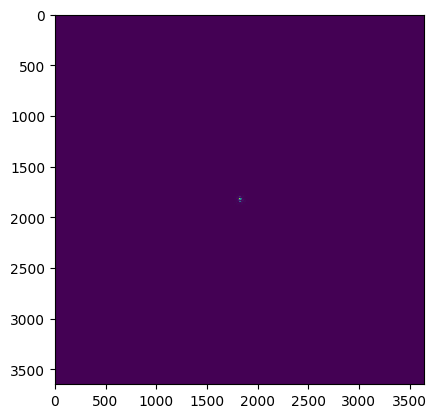

In [16]:
plt.imshow(decompress_image, aspect=1, interpolation='nearest');

/tmp/ipykernel_6639/4286247179.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(decompress_image-raw_image)), aspect=1, interpolation='nearest');


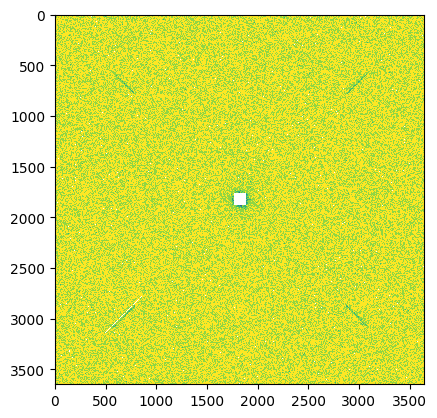

In [82]:
plt.imshow(np.log(np.abs(decompress_image-raw_image)), aspect=1, interpolation='nearest');

In [18]:
def place_core(image, core, header):

    x_pos = header['CENTR_X']
    y_pos = header['CENTR_Y']

    size = core.shape[0]
    half_size = size//2
    
    start_x = max(x_pos - half_size, 0)
    start_y = max(y_pos - half_size, 0)
    end_x = min(x_pos + half_size + (core_size % 2), image.shape[1])
    end_y = min(y_pos + half_size + (core_size % 2), image.shape[0])
    
    image[start_y:end_y, start_x:end_x] = core

    return image

In [19]:
decomp = np.zeros_like(raw_image)

In [20]:
decomp = place_core(decomp, core, header)

/tmp/ipykernel_6639/3764756677.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(decomp-raw_image)), aspect=1, interpolation='nearest');


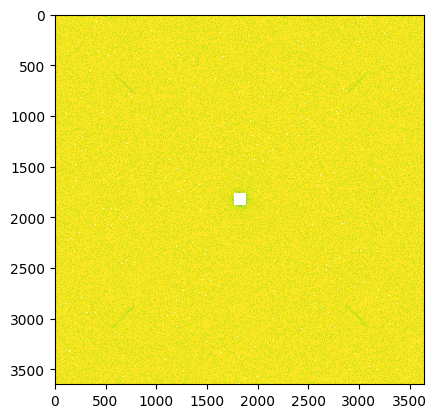

In [21]:
plt.imshow(np.log(np.abs(decomp-raw_image)), aspect=1, interpolation='nearest');

In [22]:
sidelobes.shape[0]//8

360

In [23]:
header

{'SEQNUM': 0,
 'CAMTIME': '22540362524944',
 'COMTIME': '2025-04-08 15:55:43.682742',
 'EXPOSURE': 46.0,
 'PXLFMT': 'Mono16',
 'XOFF': 912,
 'YOFF': 0,
 'XPAD': 0,
 'YPAD': 0,
 'CENTR_X': 1824,
 'CENTR_Y': 1824,
 'STAR_1_X': 1829,
 'STAR_1_Y': 1833,
 'STAR_2_X': 1819,
 'STAR_2_Y': 1815}

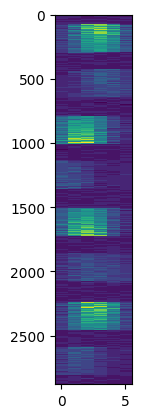

In [24]:
plt.imshow(sidelobes, aspect=0.01, interpolation='nearest')

In [25]:
image = raw_image

In [26]:
angle_degrees = 45
width = 6
SIDELOBE_OFFSET = 1625

In [27]:
angles_radians = np.array([np.deg2rad(angle_degrees), np.deg2rad(angle_degrees+90)])

In [28]:
sidelobes_x = (SIDELOBE_OFFSET * np.cos(angles_radians)).astype(int)
sidelobes_y = (SIDELOBE_OFFSET * np.sin(angles_radians)).astype(int)

In [29]:
sidelobes_x = np.concatenate((sidelobes_x, - sidelobes_x))
sidelobes_y = np.concatenate((sidelobes_y, - sidelobes_y))
angles_radians = np.concatenate((angles_radians, angles_radians))

In [30]:
y, x = np.indices(image.shape)
yy = (y - np.broadcast_to(y_poss, (*image.shape, 2)).transpose((2,0,1))).transpose((1,2,0))
xx = (x - np.broadcast_to(x_poss, (*image.shape, 2)).transpose((2,0,1))).transpose((1,2,0))

In [31]:
print(image.shape)
print(xx.shape)
print(yy.shape)

(3648, 3648)
(3648, 3648, 2)
(3648, 3648, 2)


In [32]:
crop_im = crop_areas(image, centroid_data['x'] + sidelobes_x, centroid_data['y'] + sidelobes_y)
crop_x = crop_areas(xx, centroid_data['x'] + sidelobes_x, centroid_data['y'] + sidelobes_y)
crop_y = crop_areas(yy, centroid_data['x'] + sidelobes_x, centroid_data['y'] + sidelobes_y)

In [33]:
print(crop_im.shape)
print(crop_x.shape)
print(crop_y.shape)

(4, 480, 360)
(4, 480, 360, 2)
(4, 480, 360, 2)


In [34]:
crop_im = np.transpose(crop_im, axes=(1,2,0))
crop_x = np.transpose(crop_x, axes=(1,2,3,0))
crop_y = np.transpose(crop_y, axes=(1,2,3,0))

In [35]:
print(crop_im.shape)
print(crop_x.shape)
print(crop_y.shape)

(480, 360, 4)
(480, 360, 2, 4)
(480, 360, 2, 4)


In [36]:
tan = np.tan(angles_radians)
cot = 1/tan

In [37]:
mask = np.abs(crop_x - crop_y*cot) <= width/2

In [38]:
mask.shape

(480, 360, 2, 4)

In [39]:
crop_im = np.tile(crop_im, (2,1,1,1)).transpose((3,0,2,1))
crop_x = np.tile(crop_x, (2,1,1,1)).transpose((3,0,2,1))
crop_y = np.tile(crop_y, (2,1,1,1)).transpose((3,0,2,1))

In [40]:
print(crop_im.shape)
print(crop_x.shape)
print(crop_y.shape)

(4, 2, 360, 480)
(4, 960, 2, 360)
(4, 960, 2, 360)


In [41]:
result = crop_im[mask.T]
# result_x = crop_x[mask.T]
# result_y = crop_y[mask.T]

In [42]:
result.shape

(17280,)

In [43]:
result = result.reshape(result.shape[0]//width, width)

In [44]:
result.shape

(2880, 6)

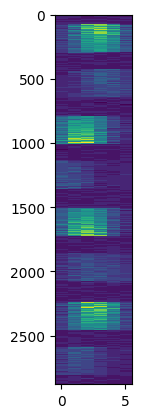

In [45]:
plt.imshow(result, aspect=0.01, interpolation='nearest');

In [47]:
header

{'SEQNUM': 0,
 'CAMTIME': '22540362524944',
 'COMTIME': '2025-04-08 15:55:43.682742',
 'EXPOSURE': 46.0,
 'PXLFMT': 'Mono16',
 'XOFF': 912,
 'YOFF': 0,
 'XPAD': 0,
 'YPAD': 0,
 'CENTR_X': 1824,
 'CENTR_Y': 1824,
 'STAR_1_X': 1829,
 'STAR_1_Y': 1833,
 'STAR_2_X': 1819,
 'STAR_2_Y': 1815}

In [49]:
header['STAR_1_X']

1829

In [50]:
x_poss

array([1829., 1819.])

In [51]:
centroid_data

{'x': np.float64(1823.500644814733),
 'y': np.float64(1823.6904068275014),
 't': '2026-02-16 15:20:06.815525'}

In [52]:
y, x = np.indices(image.shape)
x_poss = np.asarray([header['STAR_1_X'], header['STAR_2_X']])
y_poss = np.asarray([header['STAR_1_Y'], header['STAR_2_Y']])
centroid_data = {'x': header['CENTR_X'],
                 'y': header['CENTR_Y'],
                 't': header['COMTIME']}

In [89]:
image.shape

(3648, 3648)

In [90]:
def uncrop_image(core, sidelobes, header, image_dims = (3648, 3648)):
    # Create empty image
    image = np.zeros(image_dims)

    # Images of x and y indicies
    y, x = np.indices(image_dims)

    # Process header data
    centroid_data = {
        'x': header['CENTR_X'],
        'y': header['CENTR_Y'],
        't': header['COMTIME']
    }
    x_poss = np.asarray([header['STAR_1_X'], header['STAR_2_X']])
    y_poss = np.asarray([header['STAR_1_Y'], header['STAR_2_Y']])

    # Find core indices
    core_x = crop_centre(x, centroid_data["x"], centroid_data["y"])
    core_y = crop_centre(y, centroid_data["x"], centroid_data["y"])

    # Place core
    image[core_y, core_x] = core

    # Find sidelobe indices
    sidelobe_x = crop_sidelobes(x, x_poss, y_poss, centroid_data)
    sidelobe_y = crop_sidelobes(y, x_poss, y_poss, centroid_data)

    # Place sidelobes
    image[sidelobe_y, sidelobe_x] = sidelobes

    return image
    

In [92]:
restored = restore_image(core, sidelobes, header)

/tmp/ipykernel_6639/1269268333.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(restored-raw_image)), aspect=1, interpolation='nearest')


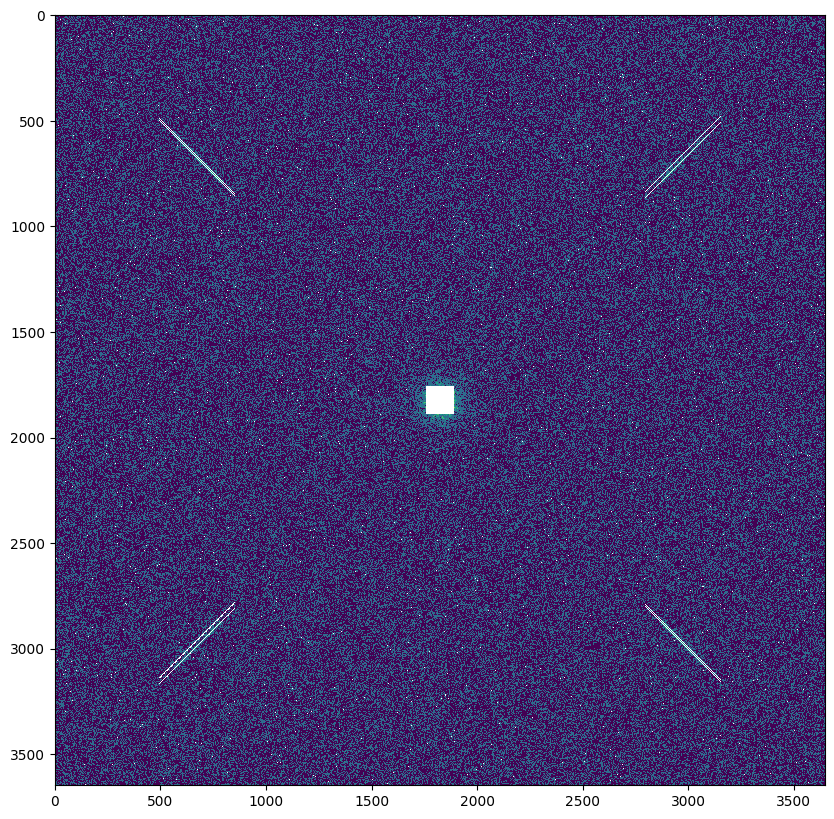

In [96]:
fig = plt.figure(figsize=(10,10))
plt.imshow(np.log(np.abs(restored-raw_image)), aspect=1, interpolation='nearest')
# plt.xlim(400,900)
# plt.ylim(400,900)
plt.show()

In [56]:
sidelobes_x = crop_sidelobes(x, x_poss, y_poss, centroid_data)
sidelobes_y = crop_sidelobes(y, x_poss, y_poss, centroid_data)

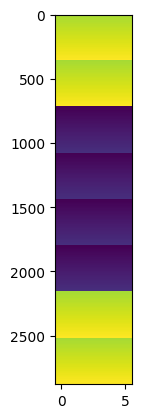

In [57]:
plt.imshow(sidelobes_x, aspect=0.01, interpolation='nearest');

In [69]:
print(np.min(sidelobes_y))
print(np.max(sidelobes_y))

479
3170


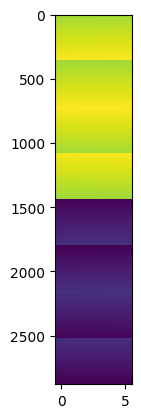

In [58]:
plt.imshow(sidelobes_y, aspect=0.01, interpolation='nearest');

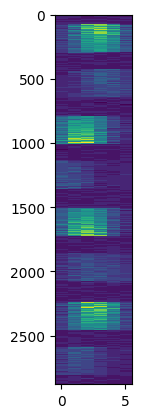

In [63]:
plt.imshow(sidelobes, aspect=0.01, interpolation='nearest');

In [64]:
decompress_image[sidelobes_y, sidelobes_x] = sidelobes

In [ ]:
plt.imshow(np.log(np.abs(decompress_image-raw_image)), aspect=1, interpolation='nearest');

/tmp/ipykernel_6639/456287294.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(decompress_image-raw_image)), aspect=1, interpolation='nearest')


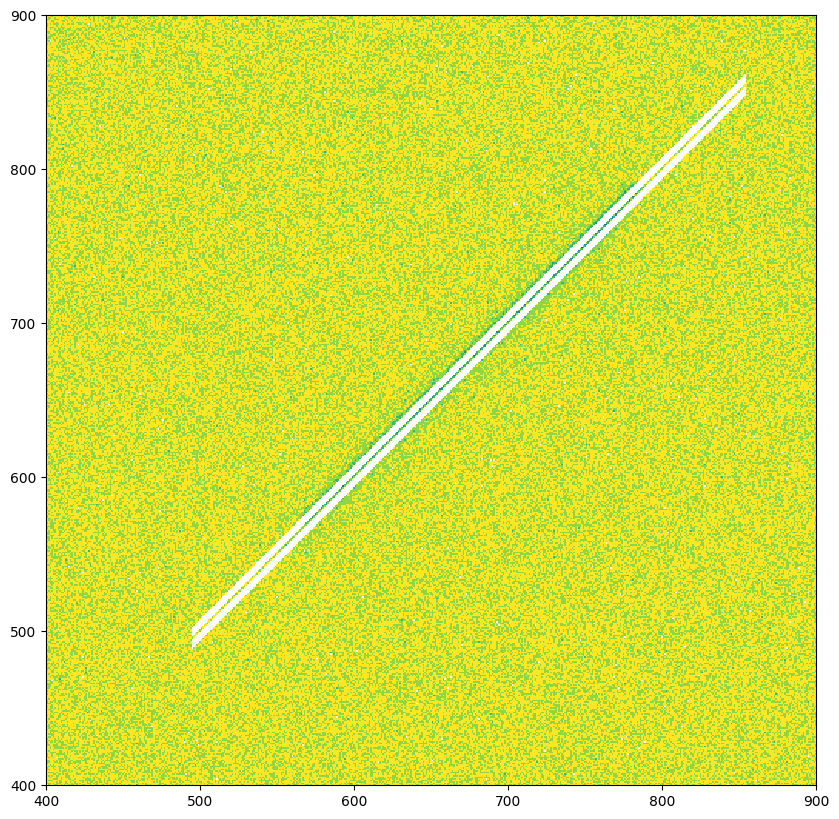

In [84]:
fig = plt.figure(figsize=(10,10))
plt.imshow(np.log(np.abs(decompress_image-raw_image)), aspect=1, interpolation='nearest')
plt.xlim(400,900)
plt.ylim(400,900)
plt.show()

/tmp/ipykernel_6639/1735907186.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(decompress_image-raw_image)), aspect=1, interpolation='nearest')


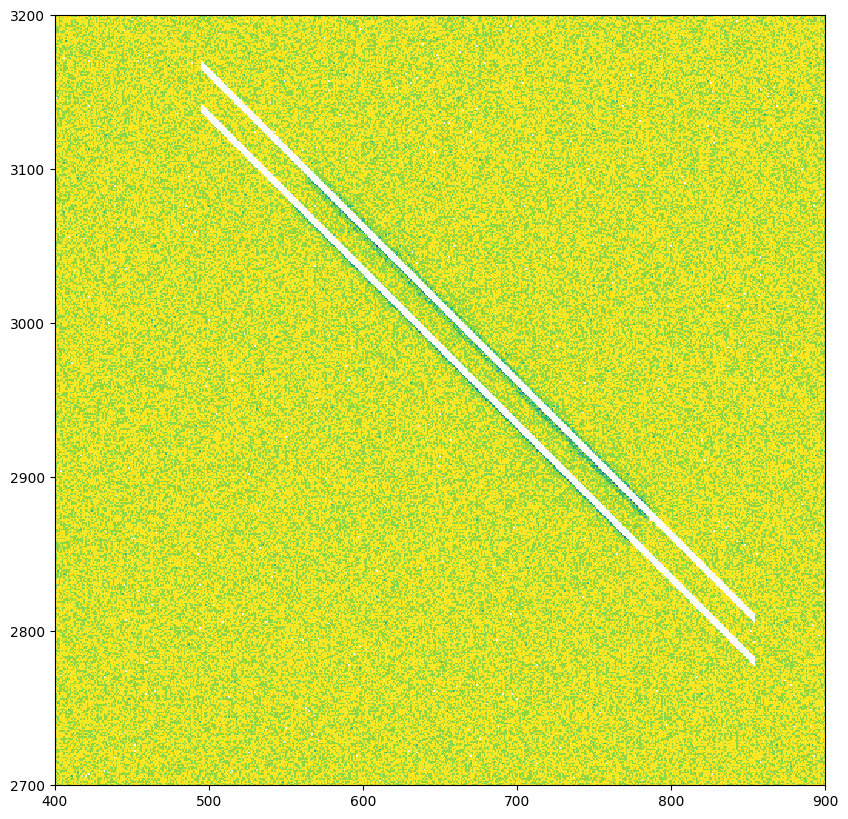

In [86]:
fig = plt.figure(figsize=(10,10))
plt.imshow(np.log(np.abs(decompress_image-raw_image)), aspect=1, interpolation='nearest')
plt.xlim(400,900)
plt.ylim(2700,3200)
plt.show()

/tmp/ipykernel_6639/3606188367.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(decompress_image-raw_image)), aspect=1, interpolation='nearest')


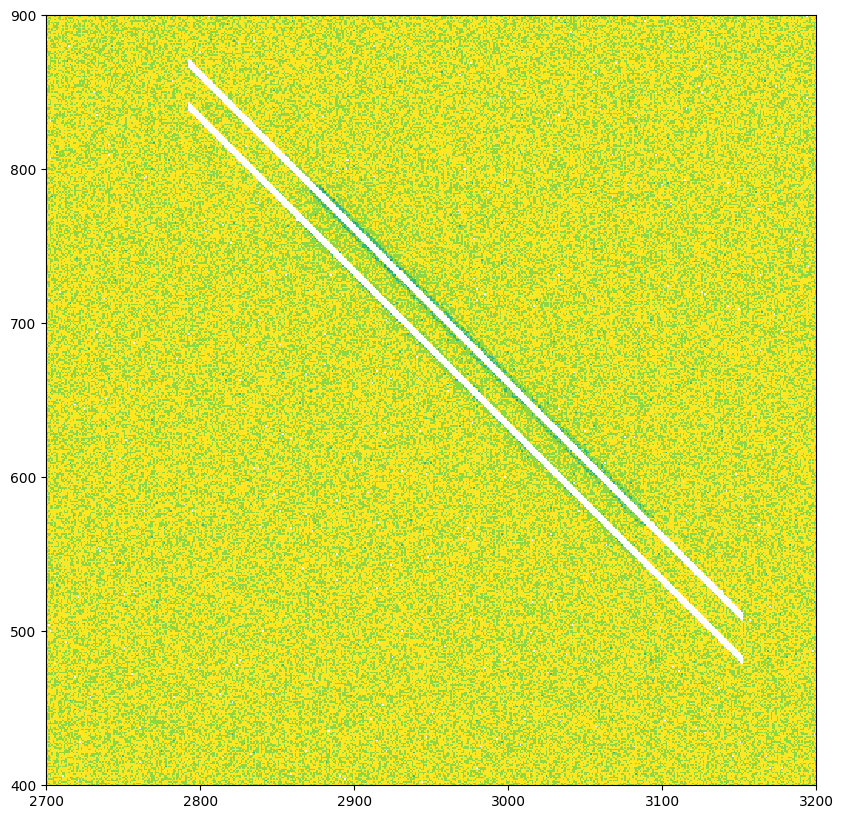

In [87]:
fig = plt.figure(figsize=(10,10))
plt.imshow(np.log(np.abs(decompress_image-raw_image)), aspect=1, interpolation='nearest')
plt.ylim(400,900)
plt.xlim(2700,3200)
plt.show()

/tmp/ipykernel_6639/2644755349.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(decompress_image-raw_image)), aspect=1, interpolation='nearest')


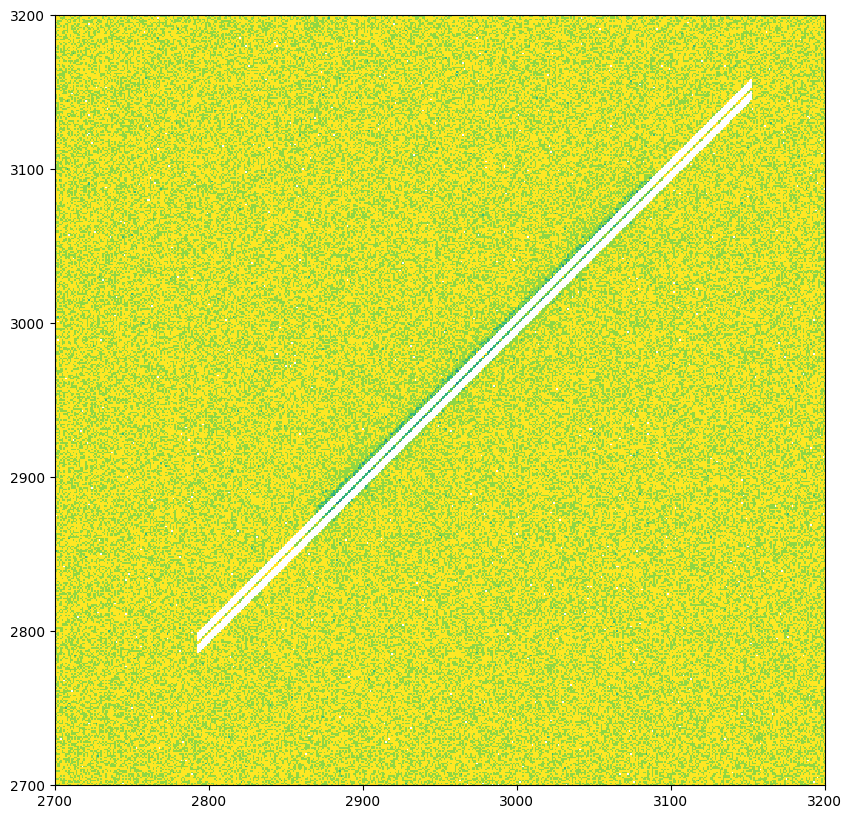

In [88]:
fig = plt.figure(figsize=(10,10))
plt.imshow(np.log(np.abs(decompress_image-raw_image)), aspect=1, interpolation='nearest')
plt.ylim(2700,3200)
plt.xlim(2700,3200)
plt.show()